# KYB Onboarding STP Risk Scoring Engine

This project simulates a fintech KYB onboarding workflow and uses Python and SQL to:
- simulate a fintech KYB onboarding pipeline
- design rule-based decision logic for STP and exception routing
- identify bottlenecks in document collection and analyst review
- quantify operational impact of manual review versus auto-approval

## Project overview

This project simulates a fintech KYB onboarding workflow using synthetic data. It combines Python for data generation and SQLite for operational analysis to examine onboarding turnaround times, risk-driven delays, and workflow bottlenecks.

In [100]:
# Import libraries for data generation, date handling, file management, and analysis
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta
import os

random.seed(42)
np.random.seed(42)

In [101]:
# Create folders for storing generated datasets and analysis outputs
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created: data/, outputs/")

Folders created: data/, outputs/


## 1. Generate customer onboarding data

This section creates a synthetic population of business customers with attributes commonly reviewed during onboarding, including geography, industry, ownership complexity, source of funds risk, and expected transaction activity.

In [102]:
# Define customer attributes used in the simulated onboarding population
countries = [
    "Singapore", "Hong Kong", "Malaysia", "Indonesia", "Philippines",
    "United Arab Emirates", "British Virgin Islands", "Cayman Islands"
]

industries = [
    "E-commerce", "Fintech", "Trading", "Consulting", "Gaming",
    "Digital Assets", "Payments", "Logistics", "Software", "Investment Holding"
]

entity_types = [
    "Private Limited Company", "LLC", "Partnership", "Sole Proprietorship"
]

ownership_levels = ["Low", "Medium", "High"]
sof_risk_levels = ["Low", "Medium", "High"]

# Identify jurisdictions and industries that will be treated as higher risk
high_risk_countries = {"British Virgin Islands", "Cayman Islands"}
higher_risk_industries = {"Digital Assets", "Gaming", "Investment Holding"}

# Generate a random application date within the past 120 days
def random_date(start_days_ago=120, end_days_ago=1):
    days_ago = random.randint(end_days_ago, start_days_ago)
    return (datetime.today() - timedelta(days=days_ago)).date()


num_customers = 120
customers = []
# Build a synthetic customer dataset with risk-sensitive attributes
for i in range(1, num_customers + 1):
    country = random.choice(countries)
    industry = random.choice(industries)
    entity_type = random.choice(entity_types)

    annual_revenue = random.randint(50000, 5000000)
    expected_monthly_txn = random.randint(5000, 500000)

    pep_flag = np.random.choice([0, 1], p=[0.9, 0.1])
    sanctions_flag = np.random.choice([0, 1], p=[0.98, 0.02])
# Customers in higher-risk segments are more likely to have complex ownership and higher source of funds risk
    if country in high_risk_countries or industry in higher_risk_industries:
        ownership_complexity = np.random.choice(ownership_levels, p=[0.2, 0.4, 0.4])
        source_of_funds_risk = np.random.choice(sof_risk_levels, p=[0.3, 0.4, 0.3])
    else:
        ownership_complexity = np.random.choice(ownership_levels, p=[0.5, 0.35, 0.15])
        source_of_funds_risk = np.random.choice(sof_risk_levels, p=[0.6, 0.3, 0.1])

    customers.append({
        "customer_id": f"CUST{i:03d}",
        "company_name": f"Company_{i:03d}",
        "country": country,
        "industry": industry,
        "entity_type": entity_type,
        "annual_revenue_usd": annual_revenue,
        "expected_monthly_txn_usd": expected_monthly_txn,
        "pep_flag": pep_flag,
        "sanctions_flag": sanctions_flag,
        "ownership_complexity": ownership_complexity,
        "source_of_funds_risk": source_of_funds_risk,
        "created_date": random_date().isoformat()
    })

customers_df = pd.DataFrame(customers)
customers_df.head()

,customer_id,company_name,country,industry,entity_type,annual_revenue_usd,expected_monthly_txn_usd,pep_flag,sanctions_flag,ownership_complexity,source_of_funds_risk,created_date
0,CUST001,Company_001,Hong Kong,E-commerce,Partnership,2104301,122026,0,0,Medium,Low,2026-03-27
1,CUST002,Company_002,Hong Kong,Software,Private Limited Company,3589336,21663,0,0,Low,Medium,2026-04-10
2,CUST003,Company_003,Hong Kong,Consulting,LLC,4289227,320631,0,0,Low,High,2026-04-10
3,CUST004,Company_004,Indonesia,Software,Sole Proprietorship,1899189,240514,0,0,Low,Low,2026-01-28
4,CUST005,Company_005,Philippines,E-commerce,LLC,3595146,183389,0,0,Low,Low,2026-03-09


In [103]:
# Save file 'data/customers.csv'
customers_df.to_csv("data/customers.csv", index=False)
print("Saved:", "data/customers.csv")
print("Shape:", customers_df.shape)

Saved: data/customers.csv
Shape: (120, 12)


In [104]:
# Review the geographic distribution of customers
customers_df["country"].value_counts()


country
Hong Kong                 23
United Arab Emirates      17
Indonesia                 15
Philippines               14
Singapore                 14
British Virgin Islands    14
Cayman Islands            12
Malaysia                  11
Name: count, dtype: int64

In [105]:
# Review the industry mix of the simulated customer population
customers_df["industry"].value_counts()

industry
Software              17
Trading               17
Digital Assets        13
Payments              11
Investment Holding    11
Consulting            11
Logistics             11
E-commerce            10
Fintech               10
Gaming                 9
Name: count, dtype: int64

In [106]:
# Inspect customers with stronger apparent risk indicators for a quick sense check
customers_df.sort_values(
    by=["sanctions_flag", "pep_flag", "expected_monthly_txn_usd"],
    ascending=[False, False, False]
).head(10)

,customer_id,company_name,country,industry,entity_type,annual_revenue_usd,expected_monthly_txn_usd,pep_flag,sanctions_flag,ownership_complexity,source_of_funds_risk,created_date
65,CUST066,Company_066,United Arab Emirates,Software,Sole Proprietorship,1346487,490366,0,1,Low,Low,2025-12-15
110,CUST111,Company_111,Hong Kong,Investment Holding,LLC,3950987,371721,0,1,Medium,Medium,2026-03-12
17,CUST018,Company_018,Cayman Islands,Trading,Partnership,1221304,134303,0,1,High,Low,2026-01-08
48,CUST049,Company_049,Hong Kong,Consulting,Sole Proprietorship,1055681,498667,1,0,Low,Low,2025-12-21
13,CUST014,Company_014,Malaysia,Logistics,Sole Proprietorship,2314486,490171,1,0,Medium,High,2026-01-22
28,CUST029,Company_029,Hong Kong,Fintech,Sole Proprietorship,630596,403774,1,0,Medium,Medium,2026-02-04
91,CUST092,Company_092,British Virgin Islands,Software,Sole Proprietorship,1385113,394889,1,0,High,High,2025-12-24
60,CUST061,Company_061,United Arab Emirates,Trading,Partnership,1405447,393618,1,0,High,Low,2026-02-16
64,CUST065,Company_065,Singapore,Digital Assets,LLC,2143207,354665,1,0,Medium,Low,2026-03-31
103,CUST104,Company_104,Singapore,Payments,Private Limited Company,754202,341985,1,0,Medium,Low,2026-02-18


### Initial observations

The generated customer population includes a mix of lower- and higher-risk profiles, with offshore jurisdictions, digital asset businesses, and higher expected transaction volumes represented in the sample.

## 2. Create KYB document records

This section simulates document collection during onboarding. Each customer is assigned multiple KYB documents with different verification outcomes to reflect operational realities such as incomplete submissions, pending checks, and rejected documents.

In [107]:
# Define common document types requested during KYB onboarding

document_types = [
    "Certificate of Incorporation",
    "Business Registration",
    "Shareholder Register",
    "UBO Declaration",
    "Proof of Address"
]

document_statuses = ["Pending", "Verified", "Rejected"]

kyb_documents = []
doc_id_counter = 1

# Generate document submissions for each customer
for _, row in customers_df.iterrows():
    customer_id = row["customer_id"]
    
    # Each customer submits between 2 and 5 documents
    num_docs = random.randint(2, 5)
    
    for _ in range(num_docs):
        doc_type = random.choice(document_types)
        
        # Most documents are verified, while some remain pending or are rejected
        status = np.random.choice(document_statuses, p=[0.2, 0.7, 0.1])
        
        submission_date = datetime.strptime(row["created_date"], "%Y-%m-%d") + timedelta(days=random.randint(1, 10))
        
        # Only verified documents receive a verification date
        if status == "Verified":
            verified_date = submission_date + timedelta(days=random.randint(1, 5))
        else:
            verified_date = None
        
        kyb_documents.append({
            "doc_id": f"DOC{doc_id_counter:04d}",
            "customer_id": customer_id,
            "document_type": doc_type,
            "document_status": status,
            "submission_date": submission_date.date().isoformat(),
            "verified_date": verified_date.date().isoformat() if verified_date else None
        })
        
        doc_id_counter += 1

kyb_documents_df = pd.DataFrame(kyb_documents)
kyb_documents_df.head()

,doc_id,customer_id,document_type,document_status,submission_date,verified_date
0,DOC0001,CUST001,Business Registration,Verified,2026-04-04,2026-04-09
1,DOC0002,CUST001,Proof of Address,Verified,2026-04-03,2026-04-06
2,DOC0003,CUST001,Certificate of Incorporation,Verified,2026-04-04,2026-04-07
3,DOC0004,CUST001,Business Registration,Verified,2026-04-04,2026-04-06
4,DOC0005,CUST001,Shareholder Register,Verified,2026-04-01,2026-04-04


In [108]:
# Save file 'data/kyb_documents.csv'
kyb_documents_df.to_csv("data/kyb_documents.csv", index=False)
print("Saved:", "data/kyb_documents.csv")
print("Shape:", kyb_documents_df.shape)

Saved: data/kyb_documents.csv
Shape: (418, 6)


In [109]:
# Check the distribution of document outcomes
kyb_documents_df["document_status"].value_counts()

document_status
Verified    285
Pending      92
Rejected     41
Name: count, dtype: int64

In [110]:
# Check how many documents were submitted per customer
kyb_documents_df.groupby("customer_id").size().head()

customer_id
CUST001    5
CUST002    4
CUST003    5
CUST004    5
CUST005    3
dtype: int64

### Initial observations

The document dataset reflects a realistic operational mix, with most submissions verified and a smaller proportion remaining pending or rejected. These non-verified outcomes will later contribute to onboarding friction and risk escalation.

## 3. Assign rule-based risk flags

This section applies rule-based logic to generate onboarding risk flags. The flags are designed to reflect common escalation drivers such as offshore jurisdictions, complex ownership, unusual expected transaction volumes, adverse media exposure, and incomplete documents.

In [111]:
# Define risk indicators commonly used in onboarding and EDD reviews

flag_types = [
    "high_risk_jurisdiction",
    "complex_ubo",
    "adverse_media",
    "unusual_expected_volume",
    "incomplete_docs"
]

severity_levels = ["Low", "Medium", "High"]

risk_flags = []
flag_id_counter = 1
# Assign risk flags to each customer based on profile attributes and document outcomes
for _, row in customers_df.iterrows():
    customer_id = row["customer_id"]
    
    flags_for_customer = []
    
    # Rule-based flags based on customer attributes
    
    # Flag offshore structures as higher-risk jurisdictions
    if row["country"] in ["British Virgin Islands", "Cayman Islands"]:
        flags_for_customer.append(("high_risk_jurisdiction", "High"))
    
    # Flag customers with highly complex ownership structures
    if row["ownership_complexity"] == "High":
        flags_for_customer.append(("complex_ubo", "High"))
    
    # Flag customers with elevated expected transaction volumes
    if row["expected_monthly_txn_usd"] > 150000:
        flags_for_customer.append(("unusual_expected_volume", "Medium"))
    
    # Randomly simulate occasional adverse media exposure
    if random.random() < 0.1:
        flags_for_customer.append(("adverse_media", "High"))
    
    # Flag customers whose KYB documents are not fully verified
    customer_docs = kyb_documents_df[kyb_documents_df["customer_id"] == customer_id]
    
    # Store all triggered flags in the risk flag dataset
    if (customer_docs["document_status"] != "Verified").any():
        flags_for_customer.append(("incomplete_docs", "Medium"))
    
    # Add flags to dataset
    for flag_type, severity in flags_for_customer:
        risk_flags.append({
            "flag_id": f"FLAG{flag_id_counter:04d}",
            "customer_id": customer_id,
            "flag_type": flag_type,
            "flag_severity": severity,
            "created_date": row["created_date"]
        })
        
        flag_id_counter += 1

risk_flags_df = pd.DataFrame(risk_flags)
risk_flags_df.head()

,flag_id,customer_id,flag_type,flag_severity,created_date
0,FLAG0001,CUST002,incomplete_docs,Medium,2026-04-10
1,FLAG0002,CUST003,unusual_expected_volume,Medium,2026-04-10
2,FLAG0003,CUST003,incomplete_docs,Medium,2026-04-10
3,FLAG0004,CUST004,unusual_expected_volume,Medium,2026-01-28
4,FLAG0005,CUST004,adverse_media,High,2026-01-28


In [112]:
# Save file 'data/risk_flags.csv'
risk_flags_df.to_csv("data/risk_flags.csv", index=False)
print("Saved:", "data/risk_flags.csv")
print("Shape:", risk_flags_df.shape)

Saved: data/risk_flags.csv
Shape: (231, 5)


In [113]:
# Review the distribution of flag types
risk_flags_df["flag_type"].value_counts()

flag_type
incomplete_docs            86
unusual_expected_volume    75
complex_ubo                30
high_risk_jurisdiction     26
adverse_media              14
Name: count, dtype: int64

In [114]:
# Review the mix of medium- and high-severity flags
risk_flags_df["flag_severity"].value_counts()

flag_severity
Medium    161
High       70
Name: count, dtype: int64

In [115]:
# Check how many flags appear per customer
risk_flags_df.groupby("customer_id").size().head()

customer_id
CUST002    1
CUST003    2
CUST004    3
CUST005    2
CUST006    1
dtype: int64

### Initial observations

Incomplete documents and unusual expected transaction volumes are the most common risk triggers in this simulated population, while adverse media and high-risk jurisdiction flags affect a smaller group of customers.

## 4. Simulate onboarding workflow events

This section creates a staged onboarding journey for each customer, from application submission through document collection, screening, review, and final approval or rejection. Customers with more risk flags are given longer delays to simulate manual review and escalation.

In [116]:
# Define the main workflow stages in the onboarding process
stages = [
    "application_submitted",
    "docs_requested",
    "docs_received",
    "screening_completed",
    "analyst_review",
    "compliance_review",
    "approved"
]

onboarding_events = []
event_id_counter = 1

# Simulate the onboarding journey for each customer
for _, row in customers_df.iterrows():
    customer_id = row["customer_id"]
    base_date = datetime.strptime(row["created_date"], "%Y-%m-%d")
    
    current_date = base_date
    
    # Use the number of risk flags as a proxy for onboarding complexity
    customer_flags = risk_flags_df[risk_flags_df["customer_id"] == customer_id]
    num_flags = len(customer_flags)
    
    # Higher-risk customers experience longer delays between workflow stages
    delay_factor = 1 + (num_flags * 0.5)
    
    # Increase delay proportionally based on risk complexity to simulate manual review effort
    for stage in stages:
        delay_days = int(random.randint(1, 3) * delay_factor)
        current_date += timedelta(days=delay_days)
        
        # Some customers are rejected during the review process
        if stage == "compliance_review" and random.random() < 0.1:
            onboarding_events.append({
                "event_id": f"EVT{event_id_counter:04d}",
                "customer_id": customer_id,
                "stage": "rejected",
                "event_status": "Completed",
                "event_date": current_date.date().isoformat()
            })
            event_id_counter += 1
            break
        
        onboarding_events.append({
            "event_id": f"EVT{event_id_counter:04d}",
            "customer_id": customer_id,
            "stage": stage,
            "event_status": "Completed",
            "event_date": current_date.date().isoformat()
        })
        
        event_id_counter += 1

onboarding_events_df = pd.DataFrame(onboarding_events)
onboarding_events_df.head()

,event_id,customer_id,stage,event_status,event_date
0,EVT0001,CUST001,application_submitted,Completed,2026-03-29
1,EVT0002,CUST001,docs_requested,Completed,2026-04-01
2,EVT0003,CUST001,docs_received,Completed,2026-04-02
3,EVT0004,CUST001,screening_completed,Completed,2026-04-04
4,EVT0005,CUST001,analyst_review,Completed,2026-04-07


In [117]:
# Save file 'data/onboarding_events.csv'
onboarding_events_df.to_csv("data/onboarding_events.csv", index=False)
print("Saved:", "data/onboarding_events.csv")
print("Shape:", onboarding_events_df.shape)

Saved: data/onboarding_events.csv
Shape: (825, 5)


In [118]:
# Review the number of events captured at each stage
onboarding_events_df["stage"].value_counts()

stage
application_submitted    120
docs_requested           120
docs_received            120
screening_completed      120
analyst_review           120
compliance_review        105
approved                 105
rejected                  15
Name: count, dtype: int64

In [119]:
# Check how many workflow events were recorded per customer
onboarding_events_df.groupby("customer_id").size().head()

customer_id
CUST001    7
CUST002    7
CUST003    7
CUST004    6
CUST005    7
dtype: int64

### Initial observations

Most customers progress through all onboarding stages to approval, while a smaller subset is rejected during the compliance review stage. Customers with more risk flags tend to accumulate longer processing times.

## 5. Load datasets into SQLite

The generated datasets are loaded into SQLite so that operational questions can be analysed using SQL. This mirrors how analysts often investigate workflow and risk data in production environments.

In [120]:
# Load all generated datasets into SQLite for SQL-based analysis
# This simulates how onboarding and risk data would be queried in a production analytics environment
import sqlite3

conn = sqlite3.connect("kyb_onboarding.db")

customers_df.to_sql("customers", conn, if_exists="replace", index=False)
kyb_documents_df.to_sql("kyb_documents", conn, if_exists="replace", index=False)
risk_flags_df.to_sql("risk_flags", conn, if_exists="replace", index=False)
onboarding_events_df.to_sql("onboarding_events", conn, if_exists="replace", index=False)

print("All tables loaded into SQLite")

All tables loaded into SQLite


## 6. Analyse onboarding performance with SQL

This section uses SQL to measure onboarding turnaround times, compare risk complexity against approval duration, and identify workflow stages that may contribute to operational bottlenecks.

In [121]:
# Measure total onboarding duration for each customer
query = """
SELECT 
    customer_id,
    MIN(event_date) AS start_date,
    MAX(event_date) AS end_date,
    JULIANDAY(MAX(event_date)) - JULIANDAY(MIN(event_date)) AS onboarding_days
FROM onboarding_events
GROUP BY customer_id
ORDER BY onboarding_days DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,customer_id,start_date,end_date,onboarding_days
0,CUST081,2025-12-31,2026-02-16,47.0
1,CUST102,2026-01-27,2026-03-10,42.0
2,CUST098,2026-02-28,2026-04-08,39.0
3,CUST038,2025-12-27,2026-02-04,39.0
4,CUST090,2026-04-02,2026-05-08,36.0
5,CUST050,2026-01-21,2026-02-25,35.0
6,CUST045,2026-02-23,2026-03-30,35.0
7,CUST112,2026-04-07,2026-05-10,33.0
8,CUST061,2026-02-18,2026-03-23,33.0
9,CUST022,2026-02-07,2026-03-12,33.0


### Insight

The longest-running onboarding cases take substantially more time than the average case, suggesting that certain customers require additional review, escalation, or document follow-up.

In [122]:
# Compare the number of risk flags against total onboarding duration
query = """
WITH onboarding_duration AS (
    SELECT
        customer_id,
        JULIANDAY(MAX(event_date)) - JULIANDAY(MIN(event_date)) AS onboarding_days
    FROM onboarding_events
    GROUP BY customer_id
),
risk_summary AS (
    SELECT
        customer_id,
        COUNT(flag_id) AS num_flags
    FROM risk_flags
    GROUP BY customer_id
)
SELECT
    r.customer_id,
    r.num_flags,
    o.onboarding_days
FROM risk_summary r
JOIN onboarding_duration o
    ON r.customer_id = o.customer_id
ORDER BY r.num_flags DESC, o.onboarding_days DESC;
"""

pd.read_sql(query, conn)

,customer_id,num_flags,onboarding_days
0,CUST081,5,47.0
1,CUST102,4,42.0
2,CUST038,4,39.0
3,CUST098,4,39.0
4,CUST090,4,36.0
...,...,...,...
107,CUST109,1,14.0
108,CUST055,1,13.0
109,CUST089,1,13.0
110,CUST105,1,13.0


### Insight

Customers with more risk flags generally show longer onboarding durations. This suggests that higher-risk cases create additional manual review effort and reduce operational efficiency. This indicates that risk-based prioritisation and early identification of high-risk customers could help reduce delays by enabling faster escalation and resource allocation.

In [123]:
# Count how many workflow events occur at each onboarding stage
query = """
SELECT 
    stage,
    COUNT(*) AS num_events
FROM onboarding_events
GROUP BY stage
ORDER BY num_events DESC;
"""

pd.read_sql(query, conn)

,stage,num_events
0,screening_completed,120
1,docs_requested,120
2,docs_received,120
3,application_submitted,120
4,analyst_review,120
5,compliance_review,105
6,approved,105
7,rejected,15


### Note

This view shows workflow volume by stage, but it does not yet measure delay. A stage appearing frequently does not necessarily mean it is a bottleneck. Delay analysis is needed to identify friction points. Stages with high volume combined with longer processing times may represent potential bottlenecks when analysed alongside delay metrics.

In [124]:
# Calculate the average time gap between workflow stages
query = """
WITH stage_gaps AS (
    SELECT
        customer_id,
        stage,
        event_date,
        JULIANDAY(event_date) - JULIANDAY(
            LAG(event_date) OVER (
                PARTITION BY customer_id
                ORDER BY event_date
            )
        ) AS days_since_previous_stage
    FROM onboarding_events
)
SELECT
    stage,
    ROUND(AVG(days_since_previous_stage), 2) AS avg_days_between_stages
FROM stage_gaps
WHERE days_since_previous_stage IS NOT NULL
GROUP BY stage
ORDER BY avg_days_between_stages DESC;
"""

pd.read_sql(query, conn)

,stage,avg_days_between_stages
0,rejected,4.33
1,docs_requested,4.07
2,analyst_review,3.89
3,approved,3.86
4,screening_completed,3.84
5,docs_received,3.81
6,compliance_review,3.48


### Insight

The largest average gaps appear around the document request and analyst review stages, indicating that customer response time and manual review activity may be key sources of onboarding delay.

Rejected cases show the largest average gap, but this group is much smaller than the approved population and may reflect selective escalation rather than a stable process average.

## 7. Key findings and business implications

Key findings from this analysis include:

- Customers with more risk flags tend to experience longer onboarding durations.
- Document issues are a major driver of risk escalation and process friction.
- The document request and analyst review stages appear to contribute materially to onboarding delays.
- A smaller subset of customers is rejected during the compliance review stage, reflecting higher-risk case attrition.

From an operations perspective, these results suggest that workflow automation, earlier document quality checks, and improved prioritisation of high-risk cases could reduce turnaround times and improve onboarding efficiency.

Additional opportunities for improvement include:

- Implementing automated document validation to reduce incomplete submissions  
- Introducing risk-based onboarding queues to prioritise high-risk cases  
- Enhancing customer communication at the document submission stage to reduce delays  

## 8. Decision Engine & STP Simulation

In [125]:
def decision_engine(row):
    if row["sanctions_flag"] == 1:
        return "Reject"
    elif row["pep_flag"] == 1 and row["ownership_complexity"] == "High":
        return "High Risk Review"
    elif row["num_flags"] >= 3:
        return "Manual Review"
    else:
        return "Auto Approve"

In [126]:
# Build risk summary with flag counts per customer
risk_summary_df = (
    risk_flags_df.groupby("customer_id")
    .size()
    .reset_index(name="num_flags")
)

# Merge flag counts back to customer dataset
decision_df = customers_df.merge(risk_summary_df, on="customer_id", how="left")
decision_df["num_flags"] = decision_df["num_flags"].fillna(0).astype(int)

# Apply decision engine
decision_df["decision"] = decision_df.apply(decision_engine, axis=1)

# Review distribution of outcomes
decision_df["decision"].value_counts()

decision
Auto Approve        86
Manual Review       29
Reject               3
High Risk Review     2
Name: count, dtype: int64

In [127]:
# Calculate decision outcome percentages
decision_distribution = (
    decision_df["decision"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

decision_distribution.columns = ["decision", "percentage"]
decision_distribution

,decision,percentage
0,Auto Approve,71.67
1,Manual Review,24.17
2,Reject,2.50
3,High Risk Review,1.67


### Insight
This decision layer simulates how a KYB onboarding team can separate lower-risk cases suitable for straight-through processing from higher-risk cases that require manual or enhanced review. In a scaled operating model, the onboarding team would increasingly focus on the exception queue rather than manually handling every application.

In [128]:
# Save decision output for downstream use
decision_df.to_csv("outputs/decision_engine_results.csv", index=False)
print("Saved: outputs/decision_engine_results.csv")

Saved: outputs/decision_engine_results.csv


In [129]:
# Load decision output into SQLite
decision_df.to_sql("decision_results", conn, if_exists="replace", index=False)

# Analyse average onboarding time by decision outcome
query = """
WITH onboarding_duration AS (
    SELECT
        customer_id,
        JULIANDAY(MAX(event_date)) - JULIANDAY(MIN(event_date)) AS onboarding_days
    FROM onboarding_events
    GROUP BY customer_id
)
SELECT
    d.decision,
    COUNT(*) AS customers,
    ROUND(AVG(o.onboarding_days), 2) AS avg_onboarding_days
FROM decision_results d
JOIN onboarding_duration o
    ON d.customer_id = o.customer_id
GROUP BY d.decision
ORDER BY avg_onboarding_days DESC;
"""
pd.read_sql(query, conn)

,decision,customers,avg_onboarding_days
0,Manual Review,29,29.17
1,High Risk Review,2,28.00
2,Reject,3,21.67
3,Auto Approve,86,20.24


## Insight
This view shows whether manual-review and high-risk-review cases consume more operational time than auto-approved cases. That helps quantify the operational value of STP and supports prioritisation of automation efforts.

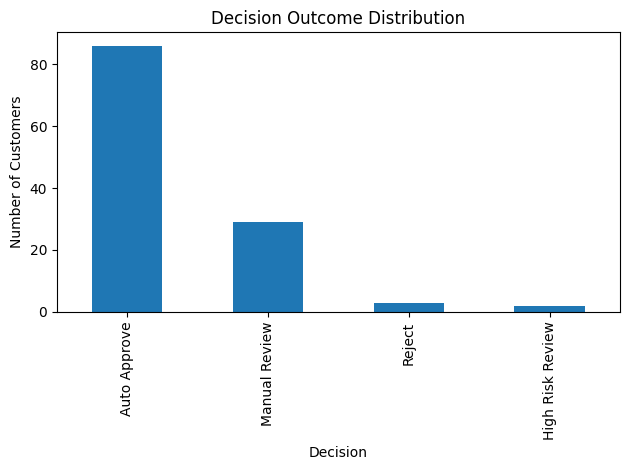

In [130]:
import matplotlib.pyplot as plt

decision_df["decision"].value_counts().plot(kind="bar")
plt.title("Decision Outcome Distribution")
plt.xlabel("Decision")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Most cases fall into Auto Approve, suggesting meaningful STP potential if low-risk cases are routed through controlled automation while higher-risk cases remain in manual queues.

This simulation results in an estimated STP rate of ~72%, with the remaining cases routed to manual or enhanced review

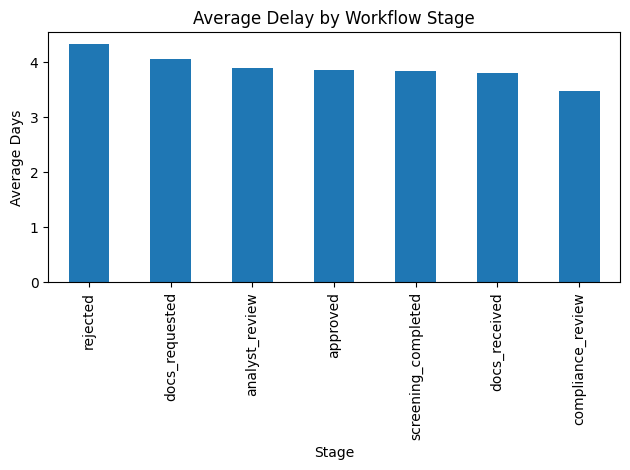

In [131]:
avg_days_by_stage = pd.read_sql("""
WITH stage_gaps AS (
    SELECT
        customer_id,
        stage,
        event_date,
        JULIANDAY(event_date) - JULIANDAY(
            LAG(event_date) OVER (
                PARTITION BY customer_id
                ORDER BY event_date
            )
        ) AS days_since_previous_stage
    FROM onboarding_events
)
SELECT
    stage,
    ROUND(AVG(days_since_previous_stage), 2) AS avg_days_between_stages
FROM stage_gaps
WHERE days_since_previous_stage IS NOT NULL
GROUP BY stage
ORDER BY avg_days_between_stages DESC;
""", conn)

ax = avg_days_by_stage.plot(x="stage", y="avg_days_between_stages", kind="bar", legend=False)
plt.title("Average Delay by Workflow Stage")
plt.xlabel("Stage")
plt.ylabel("Average Days")
plt.tight_layout()
plt.show()

Delays cluster around document and review stages, reinforcing that document quality and exception handling are major constraints on onboarding throughput.

## 9. STP Performance Metrics

In [132]:
total = len(decision_df)

metrics = {
    "STP Rate (%)": round((decision_df["decision"] == "Auto Approve").mean() * 100, 2),
    "Manual Review Rate (%)": round((decision_df["decision"] == "Manual Review").mean() * 100, 2),
    "Reject Rate (%)": round((decision_df["decision"] == "Reject").mean() * 100, 2),
    "High Risk Review (%)": round((decision_df["decision"] == "High Risk Review").mean() * 100, 2)
}

pd.DataFrame(metrics.items(), columns=["Metric", "Value"])

,Metric,Value
0,STP Rate (%),71.67
1,Manual Review Rate (%),24.17
2,Reject Rate (%),2.50
3,High Risk Review (%),1.67


## Final business implication
This project shows how KYB onboarding operations can move from manual case-by-case handling toward a more scalable STP model. By combining rule-based risk flags, exception routing, SQL-led performance analysis, and decision logic, the workflow becomes easier to monitor, tune, and automate. In a real fintech environment, this would support faster onboarding for lower-risk customers while preserving control quality for higher-risk cases requiring manual intervention.

In a fully manual onboarding model, all cases would require analyst review. Based on this simulation, introducing rule-based decisioning could reduce manual workload by ~70%, allowing teams to focus on higher-risk exception handling.

In a real fintech environment, this approach could be extended to partner onboarding, KYB automation, and API-driven onboarding flows.